In [ ]:
import torch
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
traindata = MNIST(root="./data", download=True, train=True, transform=transforms.ToTensor())
traindataloader = DataLoader(traindata, shuffle=True, num_workers=2, batch_size=64)
testdata = MNIST(root="./data", download=True, train=False, transform=transforms.ToTensor())
testdataloader = DataLoader(testdata, shuffle=False, num_workers=2, batch_size=64)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


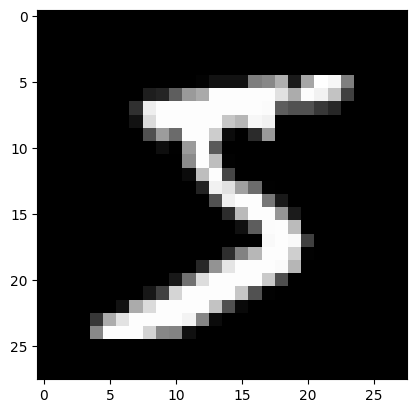

In [ ]:
image, label = traindata[0]
plt.imshow(image[0], cmap = "gray")

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.c1 = nn.Conv2d(1, 8, 5) # 1,28,28
    self.c2 = nn.Conv2d(8, 16, 5)
    self.pool = nn.MaxPool2d(2, 2)
    self.fc1 = nn.Linear(16 * 4 * 4, 256)
    self.fc2 = nn.Linear(256, 128)
    self.fc3 = nn.Linear(128, 10)

  def forward(self, x):
    c1 = self.pool(F.relu(self.c1(x)))
    c2 = self.pool(F.relu(self.c2(c1)))
    c2 = torch.flatten(c2, 1)

    f1 = F.relu(self.fc1(c2))
    f2 = F.relu(self.fc2(f1))
    f3 = self.fc3(f2)
    return f3

In [ ]:
net = Net()
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum = 0.9)

In [ ]:
net.train()

epochs = 9

for i in range(epochs):
  epochloss = 0

  for image, labels in traindataloader:
    output = net(image)
    loss = loss_func(output, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epochloss += loss

  avgloss = epochloss/len(traindataloader)
  print(f"epoch {i+1}, loss: {avgloss:.4f}")

epoch 1, loss: 0.2044
epoch 2, loss: 0.1511
epoch 3, loss: 0.1232
epoch 4, loss: 0.1050
epoch 5, loss: 0.0915
epoch 6, loss: 0.0825
epoch 7, loss: 0.0743
epoch 8, loss: 0.0684
epoch 9, loss: 0.0630


In [ ]:
net.eval()

correct = 0

with torch.no_grad():
  for image, label in testdataloader:
    output = net(image)

    _, pred = torch.max(output, 1)
    correct += (pred == label).sum().item()

score = 100 * (correct/len(testdataloader.dataset))
print(f"{score:.1f}")

98.0
